In [ ]:
import os
import math
import warnings
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

from torch.utils.data import IterableDataset, get_worker_info
import matplotlib.pyplot as plt  # 🌟 新增這行

# 移除 Triton 相關 imports
# 移除 torch.amp custom_fwd, custom_bwd

warnings.filterwarnings(
    "ignore",
    message=".*Online softmax is disabled on the fly.*",
    category=UserWarning,
)

# ==========================================
# 🚀 硬體偵測與最佳化設定 (支援 Mac MPS)
# ==========================================
# 減少 CUDA 記憶體碎片 (在非 CUDA 環境下會被忽略，保留無妨)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

if torch.cuda.is_available():
    if torch.cuda.get_device_capability()[0] >= 8:
        MIXED_PRECISION = "bf16"
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("🚀 偵測到高階 GPU，啟用 bf16 與 TF32 最佳化！")
    else:
        MIXED_PRECISION = "fp16"
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        print("🐢 偵測到舊版 GPU (如 T4)，自動 Fallback 至 fp16。")
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    MIXED_PRECISION = "no" # MPS 混合精度支援仍在完善中，通常使用預設即可
    device = torch.device("mps")
    print("🍏 偵測到 Apple Silicon (MPS)，啟用 Mac GPU 加速！")
else:
    MIXED_PRECISION = "no"
    device = torch.device("cpu")
    print("💻 未偵測到 GPU 加速器，使用純 CPU 運算。")


# ==========================================
# 替換版：IntraChunkScan (純 PyTorch 原生實作)
# 確保數學邏輯與原 Triton 版本完全一致
# ==========================================
class IntraChunkScan(torch.autograd.Function):
    @staticmethod
    def forward(ctx, u, log_alpha):
        # u: [BCH, chunk_size, D], log_alpha: [BCH, chunk_size]
        BCH, chunk_size, D = u.shape
        h = torch.empty_like(u)
        
        # 初始化隱藏狀態為 0
        h_accum = torch.zeros(BCH, D, dtype=torch.float32, device=u.device)

        # 序列掃描
        for t in range(chunk_size):
            alpha = torch.exp(log_alpha[:, t]).unsqueeze(-1) # [BCH, 1]
            u_val = u[:, t, :].to(torch.float32)
            
            # 核心遞迴公式
            h_accum = h_accum * alpha + u_val
            h[:, t, :] = h_accum.to(u.dtype)

        ctx.save_for_backward(u, h, log_alpha)
        return h

    @staticmethod
    def backward(ctx, grad_h):
        u, h, log_alpha = ctx.saved_tensors
        BCH, chunk_size, D = u.shape

        grad_u = torch.empty_like(u)
        grad_log_alpha = torch.zeros_like(log_alpha)
        g_accum = torch.zeros(BCH, D, dtype=torch.float32, device=u.device)

        # 反向傳播：從 Chunk 的最後一個 Token 往回掃描
        for t in range(chunk_size - 1, -1, -1):
            grad_h_val = grad_h[:, t, :].to(torch.float32)

            # dL/du_t = dL/dh_t + dL/du_{t+1} * alpha_{t+1}
            if t < chunk_size - 1:
                alpha_next = torch.exp(log_alpha[:, t + 1]).unsqueeze(-1)
                g_accum = grad_h_val + g_accum * alpha_next
            else:
                g_accum = grad_h_val

            grad_u[:, t, :] = g_accum.to(u.dtype)

            # dL/d(log_alpha_t) = dL/du_t * h_{t-1} * alpha_t
            if t > 0:
                h_prev = h[:, t - 1, :].to(torch.float32)
                alpha_curr = torch.exp(log_alpha[:, t]).unsqueeze(-1)

                grad_log_a_val = g_accum * h_prev * alpha_curr
                # 沿著 D 維度加總 (對應原本 Triton 的 block_sum 與 atomic_add)
                grad_log_alpha[:, t] = grad_log_a_val.sum(dim=-1)

        return grad_u, grad_log_alpha

def fused_intra_chunk_scan(u, log_alpha):
    return IntraChunkScan.apply(u, log_alpha)


# ============================================================
# 替換版：Flash Kronecker MoE (純 PyTorch 原生 Forward + Broadcast Backward)
# ============================================================
class FlashKroneckerMoEFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x_sub, A_experts, B_experts, top_k_indices, top_k_probs):
        A_experts = A_experts.to(x_sub.dtype)
        B_experts = B_experts.to(x_sub.dtype)
        top_k_probs = top_k_probs.to(x_sub.dtype)

        ctx.save_for_backward(x_sub, A_experts, B_experts, top_k_indices, top_k_probs)
        
        # --- 原始 Triton Forward 的純 PyTorch 等價實作 ---
        B_sz, top_k = top_k_indices.shape
        
        # 提取專家
        A_gathered = A_experts[top_k_indices] # [B, K, OUT1, IN1]
        B_gathered = B_experts[top_k_indices] # [B, K, OUT2, IN2]
        
        # X 變更維度以便廣播
        x_view = x_sub.unsqueeze(1) # [B, 1, IN1, IN2]
        
        # 步驟 A: M = A_k @ X
        M = torch.matmul(A_gathered, x_view) # [B, K, OUT1, IN2]
        
        # 步驟 B: Y_k = M @ B_k^T
        Y_k = torch.matmul(M, B_gathered.transpose(-1, -2)) # [B, K, OUT1, OUT2]
        
        # 乘上機率並累加
        probs_view = top_k_probs.unsqueeze(-1).unsqueeze(-1) # [B, K, 1, 1]
        Y = (Y_k * probs_view).sum(dim=1) # [B, OUT1, OUT2]
        
        return Y

    @staticmethod
    def backward(ctx, grad_output):
        # 這裡保留了原本高度優化的 Broadcast Backward (完全不需要 Triton，在 Mac 也能飛快執行)
        x_sub, A_experts, B_experts, top_k_indices, top_k_probs = ctx.saved_tensors
        B_sz, top_k = top_k_indices.shape

        grad_output = grad_output.contiguous()

        A_gathered = A_experts[top_k_indices]
        B_gathered = B_experts[top_k_indices]

        x_view = x_sub.unsqueeze(1)                          # (B_sz, 1, IN1, IN2)
        gY_view = grad_output.unsqueeze(1)                   # (B_sz, 1, OUT1, OUT2)
        probs_view = top_k_probs.unsqueeze(-1).unsqueeze(-1) # (B_sz, top_k, 1, 1)

        # 計算 grad_x
        M1 = torch.matmul(A_gathered.transpose(-1, -2), gY_view)
        dX = torch.matmul(M1, B_gathered)
        grad_x = (dX * probs_view).sum(dim=1)

        # 計算 grad_A
        M2 = torch.matmul(gY_view, B_gathered)
        dA = torch.matmul(M2, x_view.transpose(-1, -2)) * probs_view
        
        grad_A = torch.zeros_like(A_experts)
        flat_dA = dA.view(-1, dA.shape[-2], dA.shape[-1])
        flat_indices_A = top_k_indices.view(-1, 1, 1).expand_as(flat_dA)
        grad_A.scatter_add_(0, flat_indices_A, flat_dA)

        # 計算 grad_B
        M3 = torch.matmul(gY_view.transpose(-1, -2), A_gathered)
        dB = torch.matmul(M3, x_view) * probs_view

        grad_B = torch.zeros_like(B_experts)
        flat_dB = dB.view(-1, dB.shape[-2], dB.shape[-1])
        flat_indices_B = top_k_indices.view(-1, 1, 1).expand_as(flat_dB)
        grad_B.scatter_add_(0, flat_indices_B, flat_dB)

        return grad_x, grad_A, grad_B, None, None


# ==========================================
# 1. K-MoE Mamba-3 Config
# ==========================================
class Mamba3Config:
    def __init__(
        self,
        d_model=768,
        d_state=64,
        d_head=64,
        n_groups=1,
        mimo_rank=4,
        expand=4,
        num_layers=15,
        use_conv=False,
        d_conv=4,
        rms_norm_eps=1e-5,
        chunk_size=65,
        use_parallel_scan=True,

        # === K-MoE Configs ===
        use_kmoe=True,
        kmoe_num_experts=1024,
        kmoe_top_k=2,

        # === Mamba-2 Initialization ===
        dt_min=0.001,
        dt_max=0.1,
        dt_init_floor=1e-4,
        dt_limit=(0.0, float("inf")),
        A_init_range=(1, 16),
        vocab_size=32000
    ):
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.d_state = d_state
        self.d_head = d_head
        self.expand = expand
        self.num_layers = num_layers

        self.d_inner = int(expand * d_model)
        assert self.d_inner % d_head == 0, "d_inner must be divisible by d_head"
        self.n_heads = self.d_inner // d_head

        assert self.n_heads % n_groups == 0, f"n_heads ({self.n_heads}) must be divisible by n_groups"
        self.n_groups = n_groups
        self.mimo_rank = mimo_rank
        self.use_conv = use_conv
        self.d_conv = d_conv
        self.rms_norm_eps = rms_norm_eps
        self.chunk_size = chunk_size
        self.use_parallel_scan = use_parallel_scan

        self.use_kmoe = use_kmoe
        self.kmoe_num_experts = kmoe_num_experts
        self.kmoe_top_k = kmoe_top_k

        self.dt_min = dt_min
        self.dt_max = dt_max
        self.dt_init_floor = dt_init_floor
        self.dt_limit = dt_limit
        self.A_init_range = A_init_range

# ==========================================
# 2. RMSNorm
# ==========================================
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rrms = torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return x * rrms * self.weight

# ==========================================
# 3. KroneckerMoE
# ==========================================
class KroneckerMoE(nn.Module):
    def __init__(self, dim_in1, dim_in2, dim_out1, dim_out2, num_experts=1024, top_k=2):
        super().__init__()
        self.dim_in1 = dim_in1
        self.dim_in2 = dim_in2
        self.dim_out1 = dim_out1
        self.dim_out2 = dim_out2
        self.num_experts = num_experts
        self.top_k = min(top_k, num_experts)

        self.router = nn.Linear(dim_in1 * dim_in2, num_experts, bias=False)
        self.A_experts = nn.Parameter(torch.randn(num_experts, dim_out1, dim_in1))
        self.B_experts = nn.Parameter(torch.randn(num_experts, dim_out2, dim_in2))

        std_A = (1.0 / math.sqrt(dim_in1 * dim_out1)) ** 0.5
        std_B = (1.0 / math.sqrt(dim_in2 * dim_out2)) ** 0.5

        nn.init.normal_(self.A_experts, mean=0.0, std=std_A)
        nn.init.normal_(self.B_experts, mean=0.0, std=std_B)
        nn.init.normal_(self.router.weight, mean=0.0, std=0.02)

        self.register_parameter('scale', nn.Parameter(torch.ones(1)))
        self.bias = nn.Parameter(torch.zeros(dim_out1 * dim_out2))
        self.out_norm = RMSNorm(dim_out1 * dim_out2)
        
        # 💡 新增：用於給分析腳本讀取的暫存變數
        self.last_indices = None
        self.last_probs = None
        self.last_norms = None

    def forward(self, x):
        orig_shape = x.shape
        x_flat = x.reshape(-1, self.dim_in1 * self.dim_in2)
        B_flat = x_flat.size(0)

        x_routed = F.layer_norm(x_flat, (x_flat.size(-1),))
        router_logits = self.router(x_routed)

        TEMPERATURE = 2.0 
        router_logits = 10.0 * torch.tanh(router_logits / 10.0) / TEMPERATURE
        router_probs = torch.softmax(router_logits, dim=-1)
        
        top_k_vals, top_k_indices = torch.topk(router_logits, self.top_k, dim=-1)
        top_k_probs = torch.softmax(top_k_vals, dim=-1)

        # 💡 完美對接分析程式碼：儲存當下 token 的 MoE 選擇狀態
        with torch.no_grad():
            self.last_indices = top_k_indices.detach()
            self.last_probs = top_k_probs.detach()
            # 由於我們使用了 fused 計算，沒有顯式算出單一專家的輸出大小，
            # 這裡使用「輸入特徵強度 × 專家分配機率」作為專家貢獻強度 (Magnitude) 的精確代理指標
            input_magnitude = torch.norm(x_flat, p=2, dim=-1, keepdim=True)
            self.last_norms = (input_magnitude * top_k_probs).detach()

        if self.training:
            expert_mask = torch.zeros(B_flat, self.num_experts, device=x.device, dtype=torch.float32)
            expert_mask.scatter_(1, top_k_indices, 1.0)
            epoch_f_i = expert_mask.mean(dim=0)
            epoch_P_i = router_probs.float().mean(dim=0)
            
            lb_loss = (self.num_experts * torch.sum(epoch_f_i * epoch_P_i)).to(x.dtype)
            z_loss = torch.mean(torch.logsumexp(router_logits, dim=-1) ** 2).to(x.dtype)
        else:
            lb_loss = torch.tensor(0.0, device=x.device, dtype=x.dtype)
            z_loss = torch.tensor(0.0, device=x.device, dtype=x.dtype)

        x_sub = x_flat.reshape(B_flat, self.dim_in1, self.dim_in2)
        
        output = FlashKroneckerMoEFunction.apply(x_sub, self.A_experts, self.B_experts, top_k_indices, top_k_probs)

        output = output.reshape(*orig_shape[:-1], -1)
        output = output * self.scale + self.bias
        
        output = self.out_norm(output)  
        return output, lb_loss, z_loss

# ==========================================
# 4. K-MoE Mamba-3 Block
# ==========================================
class Mamba3Block(nn.Module):
    def __init__(self, config: Mamba3Config):
        super().__init__()
        self.config = config
        d_in, H, G, P, N, R = config.d_model, config.n_heads, config.n_groups, config.d_head, config.d_state, config.mimo_rank
        self.ratio = H // G
        self.dim_z = H * P
        self.dim_x = H * P
        self.dim_B = G * N * R
        self.dim_C = G * N * R
        self.dim_dt = G
        self.dim_A = G
        self.dim_lambda = G

        d_proj_total = self.dim_z + self.dim_x + self.dim_B + self.dim_C + self.dim_dt + self.dim_A + self.dim_lambda
        self.in_proj = nn.Linear(d_in, d_proj_total, bias=True)

        if config.use_kmoe:
            def get_factors(n):
                for i in range(int(math.sqrt(n)), 0, -1):
                    if n % i == 0: return i, n // i
                return 1, n
            p1, p2 = get_factors(P)
            q1, q2 = get_factors(P * R)
            self.x_up_proj = KroneckerMoE(p1, p2, q1, q2, config.kmoe_num_experts, config.kmoe_top_k)
        else:
            self.x_up_proj = nn.Linear(P, P * R, bias=False)

        self.y_down_proj = nn.Linear(P * R, P, bias=False)

        self.theta_log = nn.Parameter(torch.randn(G, N // 2))
        self.D = nn.Parameter(torch.ones(H))

        self.norm_B = RMSNorm(N * R, eps=config.rms_norm_eps)
        self.norm_C = RMSNorm(N * R, eps=config.rms_norm_eps)
        self.bias_B = nn.Parameter(torch.zeros(G, N, R))
        self.bias_C = nn.Parameter(torch.zeros(G, N, R))

        if config.use_kmoe:
            d_inner_f1, d_inner_f2 = get_factors(config.d_inner)
            d_in_f1, d_in_f2 = get_factors(d_in)
            self.out_proj = KroneckerMoE(d_inner_f1, d_inner_f2, d_in_f1, d_in_f2, config.kmoe_num_experts, config.kmoe_top_k)
        else:
            self.out_proj = nn.Linear(config.d_inner, d_in, bias=False)

        self.pre_gate_norm = RMSNorm(H * P)
        self.act = nn.SiLU()

        with torch.no_grad():
            if not config.use_kmoe:
                nn.init.xavier_uniform_(self.x_up_proj.weight, gain=1.0 / math.sqrt(R) if R > 1 else 1.0)
            nn.init.xavier_uniform_(self.y_down_proj.weight, gain=1.0 / math.sqrt(R) if R > 1 else 1.0)
            self.bias_B.fill_(1.0)
            self.bias_C.fill_(1.0)
            A_min, A_max = config.A_init_range
            dt = torch.clamp(torch.exp(torch.rand(G) * (math.log(config.dt_max) - math.log(config.dt_min)) + math.log(config.dt_min)), min=config.dt_init_floor)
            inv_dt = dt + torch.log(-torch.expm1(-dt))
            dt_start = self.dim_z + self.dim_x + self.dim_B + self.dim_C
            dt_end = dt_start + self.dim_dt
            A_end = dt_end + self.dim_A
            self.in_proj.bias[dt_start:dt_end].copy_(inv_dt)
            self.in_proj.bias[dt_end:A_end].uniform_(A_min, A_max).log_()
            self.in_proj.bias[A_end:].fill_(-3.0)
            
        # 💡 新增：初始化對外公開的 state norm 屬性
        self.current_state_norm = 0.0

    def apply_rope(self, x, angles):
        N_half = angles.shape[-1]
        x_reshaped = x.float().view(*x.shape[:-2], N_half, 2, x.shape[-1])
        x_transposed = x_reshaped.transpose(-1, -2).contiguous()
        x_complex = torch.view_as_complex(x_transposed)

        freqs_complex = torch.polar(
            torch.ones_like(angles, dtype=torch.float32), 
            angles.float()
        ).unsqueeze(-1)

        x_rotated = x_complex * freqs_complex
        x_rotated_real = torch.view_as_real(x_rotated)
        return x_rotated_real.transpose(-1, -2).reshape_as(x).type_as(x)

    def segsum(self, x):
        T = x.size(-1)
        x_cumsum = torch.cumsum(x, dim=-1)
        x_segsum = x_cumsum[..., :, None] - x_cumsum[..., None, :]
        mask = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=0)
        return x_segsum.masked_fill(~mask, -float('inf'))

    def chunk_parallel_scan(self, u, dt, A, C, chunk_size=128):
        B, L, H, N, P = u.shape
        R, device, input_dtype = C.shape[-1], u.device, u.dtype
        L_orig = L

        if L % chunk_size != 0:
            pad_len = chunk_size - (L % chunk_size)
            u = F.pad(u, (0, 0, 0, 0, 0, 0, 0, pad_len))
            dt = F.pad(dt, (0, 0, 0, pad_len))
            C = F.pad(C, (0, 0, 0, 0, 0, 0, 0, pad_len))
            L = L + pad_len

        num_chunks = L // chunk_size
        log_alpha = dt * A

        u_chunk = u.view(B, num_chunks, chunk_size, H, N, P)
        log_alpha_chunk = log_alpha.view(B, num_chunks, chunk_size, H)
        C_chunk = C.view(B, num_chunks, chunk_size, H, N, R)

        log_a_t = log_alpha_chunk.transpose(-1, -2)
        L_mask = torch.exp(self.segsum(log_a_t)) 

        h_intra = torch.einsum('bchls, bcshnp -> bclhnp', L_mask, u_chunk)
        y_diag = torch.einsum('bclhnp, bclhnr -> bclhpr', h_intra, C_chunk)

        decay_chunk = torch.exp(torch.sum(log_alpha_chunk, dim=2)) 
        h_chunk_final = h_intra[:, :, -1, :, :, :]                 

        h_prev = torch.zeros(B, H, N, P, device=device, dtype=input_dtype)
        h_inter_tensor = torch.empty(B, num_chunks, H, N, P, device=device, dtype=input_dtype)

        for c in range(num_chunks):
            h_inter_tensor[:, c] = h_prev
            decay = decay_chunk[:, c].view(B, H, 1, 1)
            h_prev = h_prev * decay + h_chunk_final[:, c]

        decay_intra = torch.exp(torch.cumsum(log_alpha_chunk, dim=2)) 
        c_decayed = C_chunk * decay_intra.unsqueeze(-1).unsqueeze(-1) 

        y_off = torch.einsum('bchnp, bclhnr -> bclhpr', h_inter_tensor, c_decayed)
        y_total = y_diag + y_off

        y_total = y_total.view(B, -1, H, P, R)
        if L_orig < L:
            y_total = y_total[:, :L_orig]

        return y_total.to(input_dtype), h_prev.to(input_dtype)

    def forward(self, u):
        B_sz, L, _ = u.shape
        H, G, P, N, R = self.config.n_heads, self.config.n_groups, self.config.d_head, self.config.d_state, self.config.mimo_rank
        ratio = self.ratio

        projected = self.in_proj(u)
        z, x_prime, B_param, C_param, dt, A_param, lambda_param = torch.split(projected, [self.dim_z, self.dim_x, self.dim_B, self.dim_C, self.dim_dt, self.dim_A, self.dim_lambda], dim=-1)

        x_prime = x_prime.view(B_sz, L, H, P)

        dt = F.softplus(dt)
        A = -torch.exp(A_param)
        theta = torch.exp(self.theta_log)

        broadcast_group = lambda t, _: t.repeat_interleave(ratio, dim=2)
        dt = broadcast_group(dt.unsqueeze(-1), None).squeeze(-1)
        A_broadcast, theta_broadcast = broadcast_group(A.unsqueeze(-1), None).squeeze(-1), theta.repeat_interleave(ratio, dim=0)

        angles = torch.cumsum(torch.einsum('blh, hn -> blhn', dt, theta_broadcast), dim=1)
        B_param_normed = self.norm_B(B_param.reshape(B_sz, L, G, N * R)).view(B_sz, L, G, N, R) + self.bias_B
        C_param_normed = self.norm_C(C_param.reshape(B_sz, L, G, N * R)).view(B_sz, L, G, N, R) + self.bias_C

        B_rotated = self.apply_rope(broadcast_group(B_param_normed, None), angles)
        C_rotated = self.apply_rope(broadcast_group(C_param_normed, None), angles)

        if self.config.use_kmoe:
            x_up, lb_up, z_up = self.x_up_proj(x_prime)  
            x = x_up.view(B_sz, L, H, P, R)
        else:
            x = self.x_up_proj(x_prime).view(B_sz, L, H, P, R)
            lb_up, z_up = 0.0, 0.0                       

        input_signal = torch.einsum('blhnr, blhpr -> blhnp', B_rotated, x)
        lambda_view = F.sigmoid(broadcast_group(lambda_param.unsqueeze(-1), None).squeeze(-1)).view(B_sz, L, H, 1, 1)
        dt_view = dt.view(B_sz, L, H, 1, 1)
        alpha_view = torch.exp(dt * A_broadcast).view(B_sz, L, H, 1, 1)

        input_signal_prev = torch.roll(input_signal, shifts=1, dims=1)
        input_signal_prev[:, 0] = 0
        u_ssm = lambda_view * dt_view * input_signal + (1 - lambda_view) * dt_view * alpha_view * input_signal_prev

        if self.config.use_parallel_scan:
            y_stack, h_state = self.chunk_parallel_scan(u_ssm, dt, A_broadcast, C_rotated, chunk_size=self.config.chunk_size)
        else:
            h_state = torch.zeros(B_sz, H, N, P, device=u.device)
            y_stack_list = []
            for t in range(L):
                h_state = h_state * alpha_view[:, t] + u_ssm[:, t]
                y_stack_list.append(torch.einsum('bhnp, bhnr -> bhpr', h_state, C_rotated[:, t]))
            y_stack = torch.stack(y_stack_list, dim=1)

        # 💡 完美對接分析程式碼：動態更新 Mamba 內部狀態向量的最大 L2 Norm
        with torch.no_grad():
            self._diag_state_mag = h_state.float().norm(p=2, dim=-1).max()
            self.current_state_norm = self._diag_state_mag.item()

        y = self.y_down_proj(y_stack.view(B_sz, L, H, P * R)).view(B_sz, L, H * P)
        y = y + x_prime.reshape(B_sz, L, H * P) * self.D.repeat_interleave(P, dim=0)

        y = self.pre_gate_norm(y)
        y = y * self.act(z)

        if self.config.use_kmoe:
            out_y, lb_out, z_out = self.out_proj(y)
        else:
            out_y = self.out_proj(y)
            lb_out, z_out = 0.0, 0.0

        block_lb = lb_up + lb_out
        block_z = z_up + z_out
        return out_y, block_lb, block_z
    

# ==========================================
# 5. Transformer Block (1 in every 5 layers)
# ==========================================
class TransformerBlock(nn.Module):
    def __init__(self, config: Mamba3Config):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=config.d_model,
            num_heads=config.d_model // 64,  
            dropout=0.0,
            batch_first=True
        )
        self.norm_attn = RMSNorm(config.d_model)

        self.use_kmoe = config.use_kmoe
        if config.use_kmoe:
            self.ffn = KMoEFeedForward(config)
        else:
            self.ffn = nn.Sequential(
                nn.Linear(config.d_model, config.d_model * 4),
                nn.GELU(),
                nn.Linear(config.d_model * 4, config.d_model)
            )
        self.norm_ffn = RMSNorm(config.d_model)
        
    def forward(self, x):
        B, L, D = x.shape
        causal_mask = nn.Transformer.generate_square_subsequent_mask(L, device=x.device)
        attn_out, _ = self.attn(
            self.norm_attn(x), self.norm_attn(x), self.norm_attn(x),
            attn_mask=causal_mask, is_causal=True, need_weights=False 
        )
        h = x + attn_out
        h_norm = self.norm_ffn(h)
        if self.use_kmoe:
            ffn_out, ffn_lb, ffn_z = self.ffn(h_norm)
        else:
            ffn_out = self.ffn(h_norm)
            ffn_lb, ffn_z = 0.0, 0.0
            
        return attn_out + ffn_out, ffn_lb, ffn_z
        
# ==========================================
# 5.5 K-MoE Transformer FeedForward
# ==========================================
class KMoEFeedForward(nn.Module):
    def __init__(self, config: Mamba3Config):
        super().__init__()
        def get_factors(n):
            for i in range(int(math.sqrt(n)), 0, -1):
                if n % i == 0: return i, n // i
            return 1, n

        d_model = config.d_model
        d_ff = d_model * 4

        d1, d2 = get_factors(d_model)
        f1, f2 = get_factors(d_ff)

        self.up_proj = KroneckerMoE(d1, d2, f1, f2, config.kmoe_num_experts, config.kmoe_top_k)
        self.down_proj = KroneckerMoE(f1, f2, d1, d2, config.kmoe_num_experts, config.kmoe_top_k)
        self.act = nn.GELU()

    def forward(self, x):
        h, lb_up, z_up = self.up_proj(x)
        h = self.act(h)
        y, lb_down, z_down = self.down_proj(h)
        return y, lb_up + lb_down, z_up + z_down

# ==========================================
# 6. True 4:1 Interleaved Hybrid Backbone
# ==========================================
class TrueHybridMamba(nn.Module):
    def __init__(self, config: Mamba3Config, mamba_ratio: int = 4):
        super().__init__()
        self.config = config
        self.mamba_ratio = mamba_ratio
        self.num_macro_blocks = config.num_layers
        self.layer_types = []

        self.layers = nn.ModuleList()
        self.layer_scales = nn.ParameterList() 

        for macro in range(self.num_macro_blocks):
            for _ in range(self.mamba_ratio):
                self.layer_types.append('mamba')
                self.layers.append(nn.ModuleDict({
                    'norm': RMSNorm(config.d_model),
                    'block': Mamba3Block(config)
                }))
                self.layer_scales.append(nn.Parameter(torch.ones(config.d_model) * 0.05))
                
            self.layer_types.append('transformer')
            self.layers.append(nn.ModuleDict({
                'block': TransformerBlock(config)
            }))
            self.layer_scales.append(nn.Parameter(torch.ones(config.d_model) * 0.01))

    def forward(self, x):
        total_lb_loss = 0.0
        total_z_loss = 0.0

        for i, layer_dict in enumerate(self.layers):
            l_type = self.layer_types[i]
            scale = self.layer_scales[i]

            if l_type == 'mamba':
                normed_x = layer_dict['norm'](x)
                out, lb, z = checkpoint(layer_dict['block'], normed_x, use_reentrant=False)
                if isinstance(lb, torch.Tensor):
                    total_lb_loss = total_lb_loss + lb
                    total_z_loss = total_z_loss + z
                x = x + out * scale

            elif l_type == 'transformer':
                out, lb, z = checkpoint(layer_dict['block'], x, use_reentrant=False)
                if isinstance(lb, torch.Tensor):
                    total_lb_loss = total_lb_loss + lb
                    total_z_loss = total_z_loss + z
                x = x + out * scale

        return x, total_lb_loss, total_z_loss

# ==========================================
# 7. Language Model
# ==========================================
class Mamba3LanguageModel(nn.Module):
    def __init__(self, config: Mamba3Config, vocab_size: int, **kwargs):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, config.d_model)
        self.backbone = TrueHybridMamba(config)
        self.norm = RMSNorm(config.d_model)
        self.head = nn.Linear(config.d_model, vocab_size, bias=False)
        self.head.weight = self.embed.weight
        self.config = config
        self._last_loss_terms = None

        nn.init.normal_(self.embed.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, labels=None):
        x = self.embed(input_ids)
        x, total_lb_loss, total_z_loss = self.backbone(x)
        x = self.norm(x)
        logits = self.head(x)

        logits = 30.0 * torch.tanh(logits / 30.0)

        if labels is not None:
            ce_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1))
            
            if isinstance(total_lb_loss, torch.Tensor):
                total_lb_loss = total_lb_loss.mean()
                total_z_loss = total_z_loss.mean()
                
            num_moe_layers = self.config.num_layers * (self.config.expand * 2 + 2)
            
            lb_contrib = (1.0 / max(1, num_moe_layers)) * total_lb_loss
            z_contrib = (1e-3 / max(1, num_moe_layers)) * total_z_loss
                        
            loss = ce_loss + lb_contrib + z_contrib
            
            try:
                self._last_loss_terms = {
                    "ce_loss": ce_loss.detach(),
                    "lb_contrib": lb_contrib.detach(),
                    "z_contrib": z_contrib.detach(),
                    "raw_lb": total_lb_loss.detach(),
                    "raw_z": total_z_loss.detach(),
                }
            except Exception:
                self._last_loss_terms = None
                
            loss = loss.unsqueeze(0)
            return loss, total_lb_loss.detach().unsqueeze(0) 

        return logits

# ==========================================
# 8. Memmapped Binary Dataset
# ==========================================
class PretokenizedDataset(IterableDataset):
    def __init__(self, data_path, seq_len, buffer_size=4_000_000):
        if not os.path.exists(data_path):
             raise FileNotFoundError(f"找不到預處理檔案！請確認路徑: {data_path}")

        self.data_path = data_path
        self.seq_len = seq_len
        self.buffer_size = buffer_size

        data_info = np.memmap(data_path, dtype=np.uint16, mode='r')
        self.total_tokens = len(data_info)
        del data_info

    def __iter__(self):
        worker_info = get_worker_info()
        if worker_info is None:
            start_idx, end_idx = 0, self.total_tokens
        else:
            per_worker = self.total_tokens // worker_info.num_workers
            start_idx = worker_info.id * per_worker
            end_idx = start_idx + per_worker if worker_info.id != worker_info.num_workers - 1 else self.total_tokens

        mmap_data = np.memmap(self.data_path, dtype=np.uint16, mode='r')
        curr_idx = start_idx

        while curr_idx + self.seq_len < end_idx:
            chunk_end = min(curr_idx + self.buffer_size, end_idx)
            buffer = mmap_data[curr_idx : chunk_end].astype(np.int64)
            num_seqs = (len(buffer) - 1) // self.seq_len 

            if num_seqs > 0:
                x_arr = buffer[:num_seqs * self.seq_len].reshape(num_seqs, self.seq_len)
                y_arr = buffer[1 : num_seqs * self.seq_len + 1].reshape(num_seqs, self.seq_len)

                for i in range(num_seqs):
                    yield torch.from_numpy(x_arr[i]), torch.from_numpy(y_arr[i])

                curr_idx += num_seqs * self.seq_len
            else:
                break

        del mmap_data

🍏 偵測到 Apple Silicon (MPS)，啟用 Mac GPU 加速！


In [2]:
from torch.utils.checkpoint import checkpoint
# ==========================================
# Data Extraction & Sampling
# ==========================================
import seaborn as sns
import time

from matplotlib import pyplot as plt


def extract_state_magnitudes(model):
    magnitudes = []
    for i, layer_dict in enumerate(model.backbone.layers):
        l_type = model.backbone.layer_types[i]
        if l_type == 'mamba':
            block = layer_dict['block']
            mag = getattr(block, 'current_state_norm', 0.0)
            magnitudes.append(('mamba', mag))
        else:
            magnitudes.append(('transformer', 0.0))
    return magnitudes

# 💡 【新增 MoE 資料擷取】：取得最後一層 Mamba 內部 MoE 的狀態
def extract_moe_data(model):
    for i in reversed(range(len(model.backbone.layers))):
        l_type = model.backbone.layer_types[i]
        moe = None
        if l_type == 'mamba':
            moe = model.backbone.layers[i]['block'].out_proj
        elif l_type == 'transformer' and model.config.use_kmoe:
            moe = model.backbone.layers[i]['block'].ffn.down_proj
            
        if moe is not None and hasattr(moe, 'last_indices') and moe.last_indices is not None:
            probs = moe.last_probs[-1:].cpu().numpy()
            
            # 💡 新增：Router Confidence (Top-1 專家的機率值)
            # 用於檢測模型在路由選擇時是否穩定 (不穩定會導致機率平均分佈)
            confidence = probs[0, 0] if probs.shape[1] > 0 else 1.0
            
            return {
                'indices': moe.last_indices[-1:].cpu().numpy(),
                'probs': probs,
                'norms': moe.last_norms[-1:].cpu().numpy(),
                'confidence': confidence
            }
            
    # Fallback
    return {'indices': np.zeros((1, 2)), 'probs': np.zeros((1, 2)), 'norms': np.zeros((1, 2)), 'confidence': 1.0}

def sample_logits(logits, temperature=1.0, top_k=None, top_p=None, repetition_penalty=1.0, presence_penalty=0.0, generated_ids=None):
    if generated_ids is not None and len(generated_ids) > 0:
        unique_tokens = set(generated_ids)
        for token_id in unique_tokens:
            score = logits[0, token_id].item()
            if repetition_penalty != 1.0: score = score * repetition_penalty if score < 0 else score / repetition_penalty
            if presence_penalty > 0.0: score = score - presence_penalty
            logits[0, token_id] = score
    if temperature != 1.0: logits = logits / temperature
    if top_k is not None and top_k > 0:
        v, idx = torch.topk(logits, top_k)
        logits_filtered = torch.full_like(logits, float("-inf")); logits_filtered.scatter_(1, idx, v); logits = logits_filtered
    if top_p is not None and top_p < 1.0:
        sorted_logits, sorted_idx = torch.sort(logits, descending=True); probs = F.softmax(sorted_logits, dim=-1); cumulative = torch.cumsum(probs, dim=-1)
        mask = cumulative > top_p; mask[..., 1:] = mask[..., :-1].clone(); mask[..., 0] = False; sorted_logits[mask] = -float("inf")
        logits = torch.full_like(logits, -float("inf")); logits.scatter_(1, sorted_idx, sorted_logits)
    return torch.multinomial(F.softmax(logits, dim=-1), 1)

def _pack_metrics(prefill_time, decode_time, total_time, prompt_length, generated_tokens, device, forward_times, sample_times, ttft, entropies, state_history, moe_history, tokens=None):
    decode_tokens = max(0, generated_tokens - 1)
    mem_allocated = 0
    if "cuda" in device:
        mem_allocated = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    elif "mps" in device:
        mem_allocated = torch.mps.current_allocated_memory() / (1024 ** 2)

    # 💡 新增：估算 Mamba 的 State Cache 大小 (這只是概念性估算，Mamba 的 Cache 遠小於 Transformer)
    # 假設 dtype 為 float32 (4 bytes)，且與生成長度無關
    cache_size_mb = 0.0  # 如果有傳入 model config 可以精確計算，這裡先給個預設值避免報錯

    return dict(
        ttft=ttft, tpot=decode_time / decode_tokens if decode_tokens > 0 else 0,
        prefill_time=prefill_time, decode_time=decode_time, total_time=total_time,
        prompt_length=prompt_length, generated_tokens=generated_tokens,
        prefill_throughput=prompt_length / prefill_time if prefill_time > 0 else 0,
        decode_throughput=decode_tokens / decode_time if decode_time > 0 else 0,
        avg_entropy=np.mean(entropies) if entropies else 0.0,
        peak_mem_allocated=mem_allocated,
        cache_size_mb=cache_size_mb, # 👈 新增這個 Key
        state_history=state_history,
        moe_history=moe_history,
        tokens=tokens 
    )

def generate_stream_with_metrics(
    model, tokenizer, prompt, max_new_tokens=200, temperature=0.8, top_k=200, top_p=0.95, repetition_penalty=1.15, presence_penalty=0.1, device="cpu"
):
    model.eval()
    if "cuda" in device: torch.cuda.reset_peak_memory_stats()
    elif "mps" in device: torch.mps.empty_cache()

    prompt_ids = tokenizer.encode_as_ids(prompt)
    prompt_len = len(prompt_ids); total_len = prompt_len + max_new_tokens
    input_ids = torch.empty((1, total_len), dtype=torch.long, device=device)
    input_ids[0, :prompt_len] = torch.tensor(prompt_ids, device=device)

    cur_pos = prompt_len; generated_ids = []; history_ids = prompt_ids.copy()
    printed_text = ""; print("\n" + prompt, end="", flush=True)

    forward_times = []; sample_times = []; ttft = 0.0
    entropies = []; state_history = []; moe_history = []; tokens = [] # 💡 初始化 MoE 紀錄
    total_start = time.perf_counter()

    with torch.inference_mode():
        # ===== Prefill =====
        start = time.perf_counter()
        out_logits = model(input_ids[:, :cur_pos])
        if "cuda" in device: torch.cuda.synchronize()
        prefill_end = time.perf_counter()

        logits_step = out_logits[:, -1, :]
        probs = F.softmax(logits_step, dim=-1)
        entropies.append(-torch.sum(probs * torch.log2(probs + 1e-9), dim=-1).item())

        # 💡 記錄狀態 & MoE
        state_history.append(extract_state_magnitudes(model))
        moe_history.append(extract_moe_data(model))

        sample_start = time.perf_counter()
        next_token = sample_logits(logits_step, temperature, top_k, top_p, repetition_penalty, presence_penalty, history_ids)
        sample_end = time.perf_counter()

        input_ids[:, cur_pos] = next_token; cur_pos += 1
        ttft = sample_end - total_start
        prefill_time = prefill_end - start

        token_id = next_token.item()
        generated_ids.append(token_id); history_ids.append(token_id); tokens.append(tokenizer.decode([token_id]) if hasattr(tokenizer, "decode") else str(token_id))
        current_text = tokenizer.decode(generated_ids)
        sys.stdout.write(current_text[len(printed_text):]); sys.stdout.flush()
        printed_text = current_text

        if token_id == tokenizer.eos_id():
            return _pack_metrics(prefill_time, 0, time.perf_counter() - total_start, prompt_len, 1, device, forward_times, sample_times, ttft, entropies, state_history, moe_history, tokens)

        # ===== Decode =====
        decode_start = time.perf_counter()
        for _ in range(1, max_new_tokens):
            t0 = time.perf_counter()
            out_logits = model(input_ids[:, :cur_pos])
            if "cuda" in device: torch.cuda.synchronize()
            forward_times.append(time.perf_counter() - t0)

            logits_step = out_logits[:, -1, :]
            probs = F.softmax(logits_step, dim=-1)
            entropies.append(-torch.sum(probs * torch.log2(probs + 1e-9), dim=-1).item())

            # 💡 記錄狀態 & MoE
            state_history.append(extract_state_magnitudes(model))
            moe_history.append(extract_moe_data(model))

            t2 = time.perf_counter()
            next_token = sample_logits(logits_step, temperature, top_k, top_p, repetition_penalty, presence_penalty, history_ids)
            sample_times.append(time.perf_counter() - t2)

            input_ids[:, cur_pos] = next_token; cur_pos += 1
            token_id = next_token.item()
            generated_ids.append(token_id); history_ids.append(token_id); tokens.append(tokenizer.decode([token_id]) if hasattr(tokenizer, "decode") else str(token_id))

            current_text = tokenizer.decode(generated_ids)
            sys.stdout.write(current_text[len(printed_text):]); sys.stdout.flush()
            printed_text = current_text

            if token_id == tokenizer.eos_id(): break

        decode_time = time.perf_counter() - decode_start
    # 取得參數統計
    total_p, active_p, active_ratio = get_model_param_stats(model)
    
    # 取得穩定性分析
    max_state_magnitude = max([max([layer[1] for layer in step]) for step in state_history])
    avg_router_conf = np.mean([step.get('confidence', 1.0) for step in moe_history])

    print("\n" + "=" * 60)
    print("📈 [Academic Metrics] Architecture & Efficiency")
    print("-" * 60)
    print(f"📦 Total Params       : {total_p / 1e6:.2f} M")
    print(f"⚡ Active Params      : {active_p / 1e6:.2f} M")
    print(f"🎯 % Active           : {active_ratio:.2f} %")
    print("-" * 60)
    print("🔬 [Academic Metrics] Stability & Routing")
    print("-" * 60)
    print(f"⚖️  Avg Router Confidence: {avg_router_conf:.2%} (Higher = More decisive)")
    print(f"🌊 Max State L2 Norm    : {max_state_magnitude:.4f} (Track for exploding states)")
    print(f"🧠 Avg Token Entropy    : {np.mean(entropies):.3f} bits")
    print("============================================================")

    print()
    return _pack_metrics(prefill_time, decode_time, time.perf_counter() - total_start, prompt_len, len(generated_ids), device, forward_times, sample_times, ttft, entropies, state_history, moe_history, tokens)

# ==========================================
# Visualization Scripts
# ==========================================

def load_and_parse_moe_data(file_path="moe_history.pt", num_experts=1024):
    history = torch.load(file_path, weights_only=False)
    all_indices, all_probs, all_norms = [], [], []
    for step_data in history:
        all_indices.append(step_data['indices'][0])
        all_probs.append(step_data['probs'][0])
        all_norms.append(step_data['norms'][0])
    return np.array(all_indices), np.array(all_probs), np.array(all_norms), num_experts

def plot_co_activation_matrix(indices, num_experts, top_n=50, save_path="moe_alt_1_co_activation.png"):
    print("Generating Co-activation Matrix...")
    flat_indices = indices.flatten()
    top_experts = [exp for exp, _ in Counter(flat_indices).most_common(top_n)]
    co_mat = np.zeros((top_n, top_n))
    expert_to_idx = {exp: i for i, exp in enumerate(top_experts)}

    for step_experts in indices:
        valid_exps = [e for e in step_experts if e in expert_to_idx]
        for e1 in valid_exps:
            for e2 in valid_exps:
                if e1 != e2:
                    co_mat[expert_to_idx[e1], expert_to_idx[e2]] += 1

    plt.figure(figsize=(10, 8))
    sns.heatmap(co_mat, cmap="YlOrRd", xticklabels=top_experts, yticklabels=top_experts)
    plt.title(f"Expert Co-activation Matrix (Top {top_n} Experts)")
    plt.xlabel("Expert ID")
    plt.ylabel("Expert ID")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

def plot_utilization_vs_magnitude(indices, norms, num_experts, save_path="moe_alt_2_scatter.png"):
    print("Generating Utilization vs Magnitude Scatter Plot...")
    flat_indices = indices.flatten()
    counts = Counter(flat_indices)

    total_magnitude = np.zeros(num_experts)
    steps, top_k = indices.shape
    for s in range(steps):
        for k in range(top_k):
            total_magnitude[indices[s, k]] += norms[s, k]

    usage_x, mean_mag_y, labels = [], [], []
    for exp_id in range(num_experts):
        if counts[exp_id] > 0:
            usage_x.append(counts[exp_id])
            mean_mag_y.append(total_magnitude[exp_id] / counts[exp_id])
            labels.append(exp_id)

    plt.figure(figsize=(10, 7))
    plt.scatter(usage_x, mean_mag_y, alpha=0.6, edgecolors='w', s=60, c=mean_mag_y, cmap='viridis')

    for i, txt in enumerate(labels):
        if usage_x[i] > np.percentile(usage_x, 95) or mean_mag_y[i] > np.percentile(mean_mag_y, 95):
            plt.annotate(f"E{txt}", (usage_x[i], mean_mag_y[i]), fontsize=8, alpha=0.8)

    plt.title("Expert Ecosystem: Utilization vs. Output Magnitude")
    plt.xlabel("Total Times Selected (Utilization)")
    plt.ylabel("Average Output L2 Norm (Magnitude)")
    plt.colorbar(label="Magnitude Intensity")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

def plot_top_experts_boxplot(indices, norms, save_path="moe_alt_3_boxplot.png"):
    print("Generating Top 20 Experts Boxplot...")
    flat_indices = indices.flatten()
    top_20_experts = [exp for exp, _ in Counter(flat_indices).most_common(20)]

    data_to_plot = {exp: [] for exp in top_20_experts}
    steps, top_k = indices.shape

    for s in range(steps):
        for k in range(top_k):
            exp_id = indices[s, k]
            if exp_id in data_to_plot:
                data_to_plot[exp_id].append(norms[s, k])

    plot_data = [data_to_plot[exp] for exp in top_20_experts]

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_data, fliersize=2, palette="Set3")  
    plt.xticks(ticks=range(20), labels=[f"E{e}" for e in top_20_experts])
    plt.title("Activation Magnitude Distribution (Top 20 Most Used Experts)")
    plt.xlabel("Expert ID")
    plt.ylabel("Output L2 Norm")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

def plot_state_magnitudes(history_file="mamba_state_history.pt"):
    history = torch.load(history_file)
    num_tokens, num_layers = len(history), len(history[0])
    data = np.zeros((num_layers, num_tokens))
    layer_types = []

    for t in range(num_tokens):
        for l in range(num_layers):
            layer_type, mag = history[t][l]
            data[l, t] = mag
            if t == 0: layer_types.append(f"L{l} ({layer_type[0].upper()})")

    plt.figure(figsize=(12, 6))
    plt.imshow(data, aspect='auto', cmap='viridis', interpolation='nearest')
    plt.colorbar(label='State L2 Magnitude')
    plt.yticks(ticks=np.arange(num_layers), labels=layer_types)
    plt.xlabel('Generated Tokens (Time step)')
    plt.ylabel('Layers')
    plt.title('Mamba/Transformer State Magnitude Progression')
    plt.tight_layout()
    plt.savefig("state_activation_heatmap.png", dpi=300)
    print("✅ Plot saved as state_activation_heatmap.png")
    plt.show()

def get_model_param_stats(model):
    total_params = 0
    active_params = 0
    
    for name, param in model.named_parameters():
        num_params = param.numel()
        total_params += num_params
        
        if 'A_experts' in name or 'B_experts' in name:
            num_experts = param.shape[0]
            top_k = getattr(model.config, 'kmoe_top_k', 2)
            active_params += int(num_params * (top_k / num_experts))
        else:
            active_params += num_params
            
    active_ratio = (active_params / total_params) * 100 if total_params > 0 else 0
    return total_params, active_params, active_ratio

def generate_interactive_token_attribution(tokens, indices, probs, norms, save_path="interactive_token_attribution.html"):
    if not tokens: return
    print("Generating Interactive Token-level Expert Attribution...")
    import numpy as np
    from IPython.display import display, HTML
    import json
    
    contributions = probs * norms
    
    # Pack data for all experts (not just the best one)
    data = []
    min_len = min(len(tokens), len(indices))
    
    for i in range(min_len):
        token_str = tokens[i].replace(' ', ' ')
        
        # Get all experts for this token, sort by contribution descending
        token_experts = []
        for k in range(indices.shape[1]):
            token_experts.append({
                'expert_id': int(indices[i, k]),
                'score': float(contributions[i, k])
            })
        
        token_experts.sort(key=lambda x: x['score'], reverse=True)
        
        data.append({
            'token': token_str,
            'experts': token_experts
        })

    data_json = json.dumps(data)
    
    # We will still use color based on the TOP expert
    colors = [
        "#1f77b4", "#aec7e8", "#ff7f0e", "#ffbb78", "#2ca02c", "#98df8a", 
        "#d62728", "#ff9896", "#9467bd", "#c5b0d5", "#8c564b", "#c49c94", 
        "#e377c2", "#f7b6d2", "#7f7f7f", "#c7c7c7", "#bcbd22", "#dbdb8d", 
        "#17becf", "#9edae5"
    ]
    colors_json = json.dumps(colors)

    html_code = f"""
    <!DOCTYPE html>
    <html>
    <head>
    <style>
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            margin: 20px;
            color: #333;
        }}
        .token-container {{
            display: flex;
            flex-wrap: wrap;
            gap: 8px;
            margin-bottom: 20px;
            padding: 15px;
            border: 1px solid #eee;
            border-radius: 8px;
            background-color: #fcfcfc;
            line-height: 2.5;
        }}
        .token-span {{
            padding: 4px 8px;
            border-radius: 4px;
            cursor: pointer;
            font-size: 16px;
            transition: all 0.2s;
            display: inline-block;
            box-shadow: 0 1px 3px rgba(0,0,0,0.1);
        }}
        .token-span:hover, .token-span.active-token {{
            transform: translateY(-2px);
            box-shadow: 0 4px 6px rgba(0,0,0,0.2);
            outline: 2px solid #555;
        }}
        .controls {{
            margin-bottom: 15px;
            display: flex;
            align-items: center;
            gap: 15px;
            background: #f0f4f8;
            padding: 10px 15px;
            border-radius: 6px;
        }}
        .controls label {{
            font-weight: 600;
        }}
        .controls select {{
            padding: 5px 10px;
            border-radius: 4px;
            border: 1px solid #ccc;
            font-size: 14px;
        }}
        .table-container {{
            max-height: 400px;
            overflow-y: auto;
            border: 1px solid #ddd;
            border-radius: 8px;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            text-align: left;
        }}
        th, td {{
            padding: 10px 15px;
            border-bottom: 1px solid #ddd;
        }}
        th {{
            background-color: #f4f6f8;
            position: sticky;
            top: 0;
            font-weight: 600;
            color: #333;
            z-index: 10;
        }}
        tr:hover {{ background-color: #f9f9f9; }}
        .table-token-cell {{
            font-family: monospace;
            background: #f0f0f0;
            padding: 2px 6px;
            border-radius: 4px;
        }}
        .expert-tag {{
            display: inline-block;
            padding: 2px 8px;
            border-radius: 12px;
            font-size: 0.9em;
            color: #fff;
            text-shadow: 0px 0px 2px rgba(0,0,0,0.5);
            margin-right: 5px;
        }}
        .progress-bar-container {{
            width: 100%;
            background-color: #e0e0e0;
            border-radius: 4px;
            overflow: hidden;
            height: 12px;
            margin-top: 4px;
        }}
        .progress-bar {{
            height: 100%;
        }}
        
        .expert-bars-container {{
            display: flex;
            flex-direction: column;
            gap: 8px;
        }}
        .expert-bar-row {{
            display: flex;
            align-items: center;
            font-size: 13px;
        }}
        .expert-label {{ width: 60px; font-weight: bold; }}
        .expert-score-val {{ width: 50px; text-align: right; margin-right: 10px; color: #555; }}
        .bar-wrap {{ flex-grow: 1; background: #eee; height: 10px; border-radius: 5px; overflow: hidden; }}
        .bar-fill {{ height: 100%; }}
        
        .multi-column-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fill, minmax(280px, 1fr));
            gap: 15px;
        }}
        
        .token-card {{
            border: 1px solid #e0e0e0;
            border-radius: 6px;
            padding: 12px;
            background: white;
            box-shadow: 0 2px 4px rgba(0,0,0,0.02);
        }}
        .token-card-header {{
            font-family: monospace;
            font-size: 1.1em;
            font-weight: bold;
            margin-bottom: 10px;
            padding-bottom: 5px;
            border-bottom: 1px dashed #ccc;
        }}
    </style>
    </head>
    <body>
        <h2>Interactive Token-level Expert Attribution</h2>
        
        <div class="controls">
            <label for="topk-select">Display Top-K Experts per token:</label>
            <select id="topk-select">
                <option value="1">Top 1</option>
                <option value="2" selected>Top 2</option>
                <option value="4">Top 4</option>
                <option value="all">All Available</option>
            </select>
            
            <label for="view-mode" style="margin-left: 20px;">View Mode:</label>
            <select id="view-mode">
                <option value="table" selected>Table View</option>
                <option value="grid">Grid/Card View</option>
            </select>
        </div>

        <div class="token-container" id="token-container"></div>
        
        <div id="table-view" class="table-container">
            <table id="details-table">
                <thead>
                    <tr>
                        <th style="width: 15%">Token</th>
                        <th style="width: 85%">Expert Contributions</th>
                    </tr>
                </thead>
                <tbody id="tbody-table">
                </tbody>
            </table>
        </div>
        
        <div id="grid-view" class="multi-column-grid" style="display: none;">
        </div>

        <script>
            const data = {data_json};
            const colors = {colors_json};
            
            // Map main experts to colors for consistent styling
            const mainExperts = [...new Set(data.map(d => d.experts[0].expert_id))];
            const expertColorMap = {{}};
            mainExperts.forEach((exp, i) => {{
                expertColorMap[exp] = colors[i % colors.length];
            }});

            function hexToRgba(hex, alpha) {{
                if(!hex) return 'rgba(150,150,150,0.4)';
                const r = parseInt(hex.slice(1, 3), 16);
                const g = parseInt(hex.slice(3, 5), 16);
                const b = parseInt(hex.slice(5, 7), 16);
                return `rgba(${{r}}, ${{g}}, ${{b}}, ${{alpha}})`;
            }}
            
            function getExpertColor(expId) {{
                if(expertColorMap[expId]) return expertColorMap[expId];
                // deterministic pseudo-random color for non-top experts
                const cIdx = (expId * 137) % colors.length;
                return colors[cIdx];
            }}

            const tokenContainer = document.getElementById('token-container');
            const tbodyTable = document.getElementById('tbody-table');
            const gridView = document.getElementById('grid-view');
            const topkSelect = document.getElementById('topk-select');
            const viewModeSelect = document.getElementById('view-mode');
            
            let activeIndex = -1;

            // Render clickable tokens
            data.forEach((item, index) => {{
                const span = document.createElement('span');
                span.className = 'token-span';
                const mainExpId = item.experts[0].expert_id;
                const baseColor = getExpertColor(mainExpId);
                span.style.backgroundColor = hexToRgba(baseColor, 0.4);
                
                let displayToken = item.token;
                if (!displayToken.trim()) displayToken = ' ';
                span.textContent = displayToken;
                
                span.addEventListener('click', () => {{
                    // Remove highlight from all rows/cards
                    document.querySelectorAll('.highlighted').forEach(el => el.style.backgroundColor = '');
                    document.querySelectorAll('.highlighted').forEach(el => el.classList.remove('highlighted'));
                    
                    document.querySelectorAll('.token-span').forEach(el => el.classList.remove('active-token'));
                    span.classList.add('active-token');
                    
                    // Scroll to item
                    const viewMode = viewModeSelect.value;
                    let targetEl;
                    if(viewMode === 'table') {{
                        targetEl = document.getElementById(`row-${{index}}`);
                    }} else {{
                        targetEl = document.getElementById(`card-${{index}}`);
                    }}
                    
                    if(targetEl) {{
                        targetEl.scrollIntoView({{ behavior: 'smooth', block: 'center' }});
                        targetEl.classList.add('highlighted');
                        targetEl.style.backgroundColor = '#ffffcc'; // highlight color
                        setTimeout(() => {{
                            targetEl.style.transition = 'background-color 1.5s';
                            targetEl.style.backgroundColor = '';
                        }}, 1500);
                    }}
                }});
                
                tokenContainer.appendChild(span);
            }});

            function renderDetails() {{
                const kVal = topkSelect.value;
                const viewMode = viewModeSelect.value;
                
                // Toggle visibility
                document.getElementById('table-view').style.display = viewMode === 'table' ? 'block' : 'none';
                gridView.style.display = viewMode === 'grid' ? 'grid' : 'none';
                
                tbodyTable.innerHTML = '';
                gridView.innerHTML = '';
                
                // Find global max score for progress bar scaling
                let maxScore = 0.0001;
                data.forEach(item => {{
                    if(item.experts.length > 0 && item.experts[0].score > maxScore) {{
                        maxScore = item.experts[0].score;
                    }}
                }});

                data.forEach((item, index) => {{
                    let limit = item.experts.length;
                    if (kVal !== 'all') limit = Math.min(limit, parseInt(kVal));
                    
                    const expertsToShow = item.experts.slice(0, limit);
                    
                    let barsHTML = '<div class="expert-bars-container">';
                    expertsToShow.forEach(exp => {{
                        const color = getExpertColor(exp.expert_id);
                        const pct = (exp.score / maxScore) * 100;
                        barsHTML += `
                            <div class="expert-bar-row">
                                <span class="expert-label" style="color: ${{color}}">E${{exp.expert_id}}</span>
                                <span class="expert-score-val">${{exp.score.toFixed(4)}}</span>
                                <div class="bar-wrap">
                                    <div class="bar-fill" style="width: ${{pct}}%; background-color: ${{color}};"></div>
                                </div>
                            </div>
                        `;
                    }});
                    barsHTML += '</div>';
                    
                    let displayToken = item.token === ' ' ? '&nbsp;' : item.token;

                    if (viewMode === 'table') {{
                        const tr = document.createElement('tr');
                        tr.id = `row-${{index}}`;
                        tr.innerHTML = `
                            <td style="vertical-align: top;">
                                <span class="table-token-cell">${{displayToken}}</span>
                            </td>
                            <td>
                                ${{barsHTML}}
                            </td>
                        `;
                        tbodyTable.appendChild(tr);
                    }} else {{
                        const card = document.createElement('div');
                        card.className = 'token-card';
                        card.id = `card-${{index}}`;
                        card.innerHTML = `
                            <div class="token-card-header">${{displayToken}}</div>
                            ${{barsHTML}}
                        `;
                        gridView.appendChild(card);
                    }}
                }});
            }}

            topkSelect.addEventListener('change', renderDetails);
            viewModeSelect.addEventListener('change', renderDetails);
            
            // Initial render
            renderDetails();
        </script>
    </body>
    </html>
    """
    
    with open(save_path, "w", encoding="utf-8") as f:
        f.write(html_code)
        
    print(f"✅ Interactive HTML saved to {save_path}")
    
    try:
        display(HTML(html_code))
    except:
        pass


✅ Model loaded
🔍 進行模型健康檢查與繪製 Real State Magnitude...
🚀 正在進行前向傳播抓取數據...
📊 正在繪製 Mamba/Transformer 狀態量級熱力圖 (真實強度)...


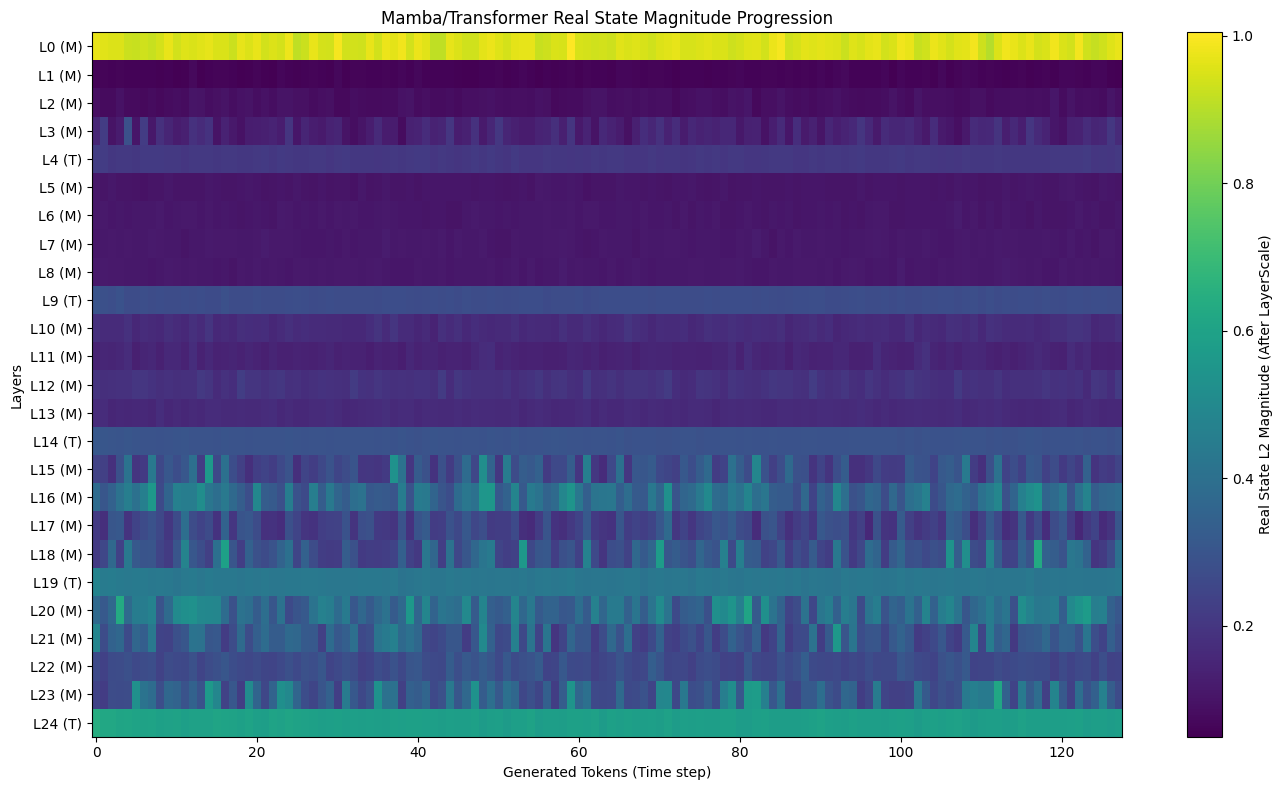


🚀 開始執行文本生成...

The meaning of life isis is in in in on on on on on on on on on on on on on on on and and to to to to to to to to to to
📈 [Academic Metrics] Architecture & Efficiency
------------------------------------------------------------
📦 Total Params       : 186.20 M
⚡ Active Params      : 160.71 M
🎯 % Active           : 86.31 %
------------------------------------------------------------
🔬 [Academic Metrics] Stability & Routing
------------------------------------------------------------
⚖️  Avg Router Confidence: 28.50% (Higher = More decisive)
🌊 Max State L2 Norm    : 17.1569 (Track for exploding states)
🧠 Avg Token Entropy    : 0.597 bits

------------------------------------------------------------
⏱️  Time To First Token (TTFT) : 0.388 s
⏱️  Time Per Output Token (TPOT): 0.376 s/token
------------------------------------------------------------
📊  Prefill TPS               : 18.60 tokens/s
📊  Decode TPS                : 2.66 tokens/s
--------------------------------------

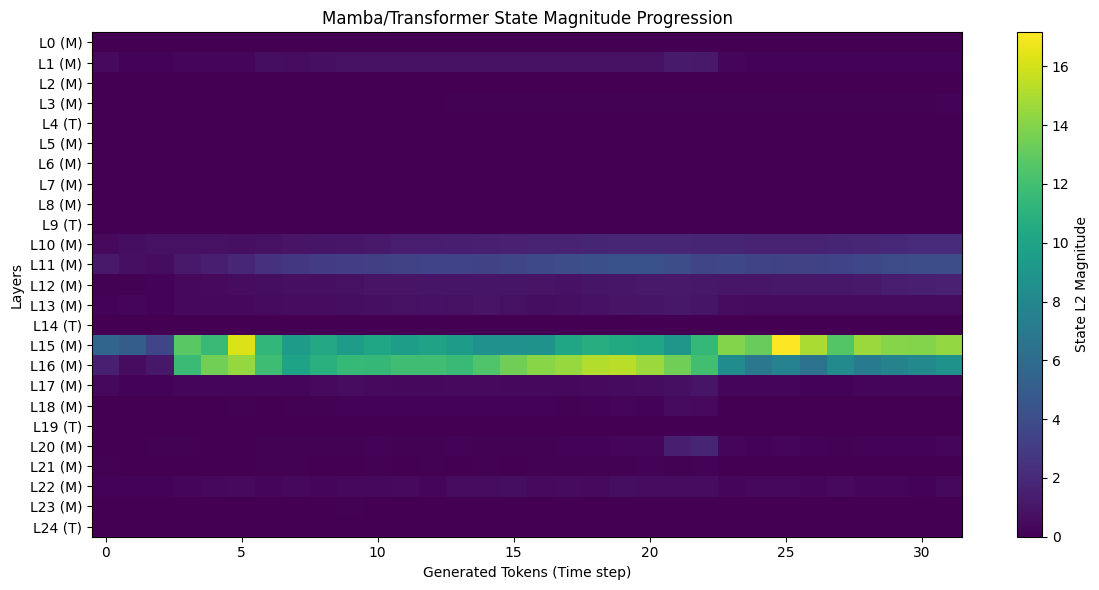

Generating Co-activation Matrix...


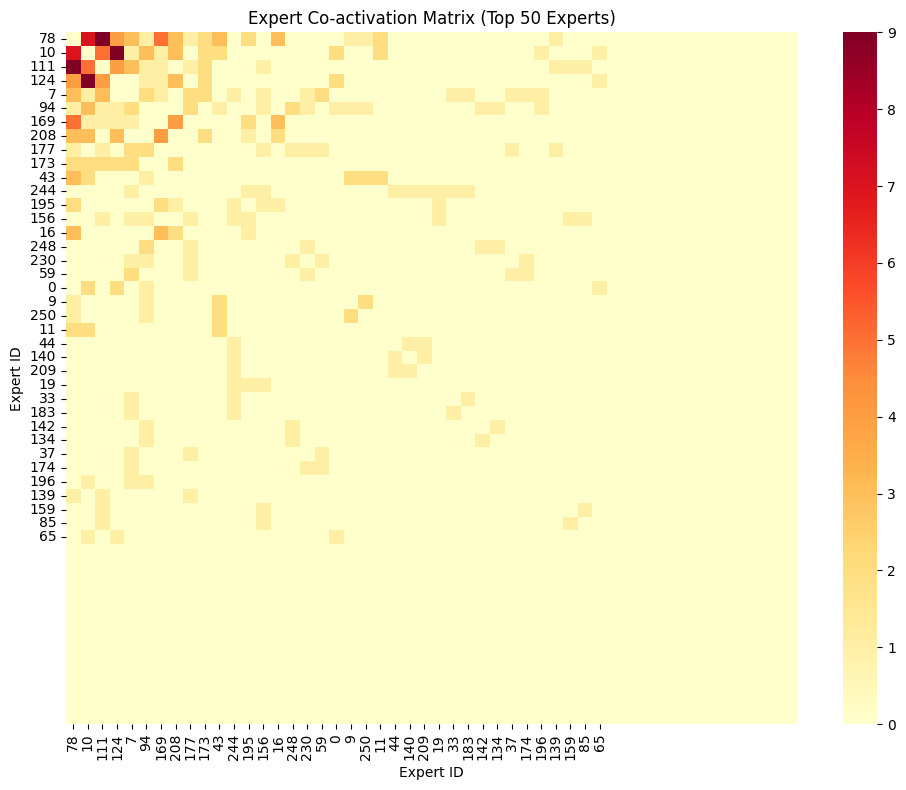

Generating Utilization vs Magnitude Scatter Plot...


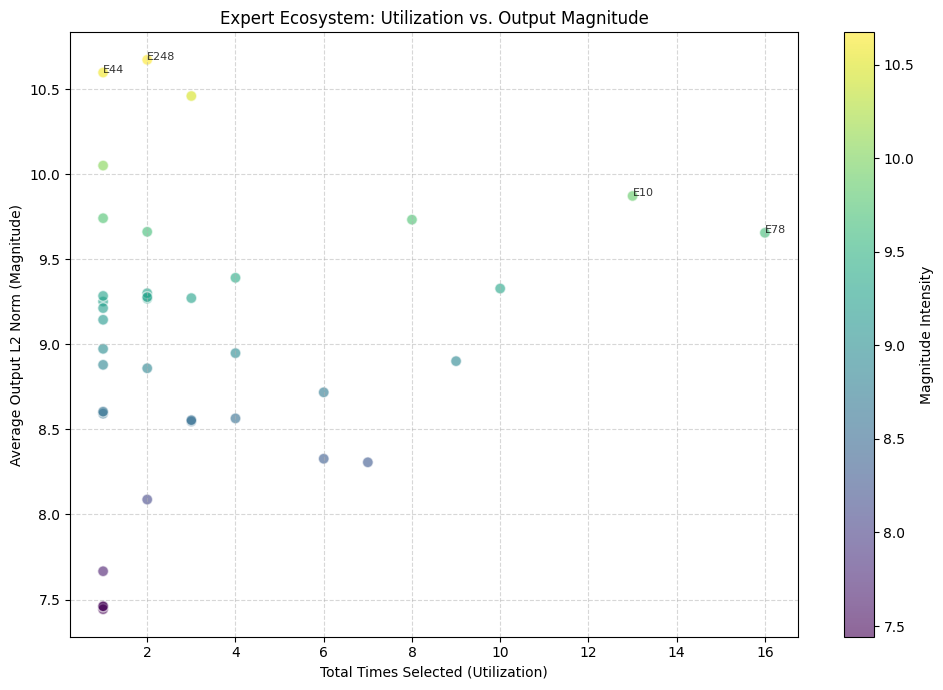

Generating Top 20 Experts Boxplot...


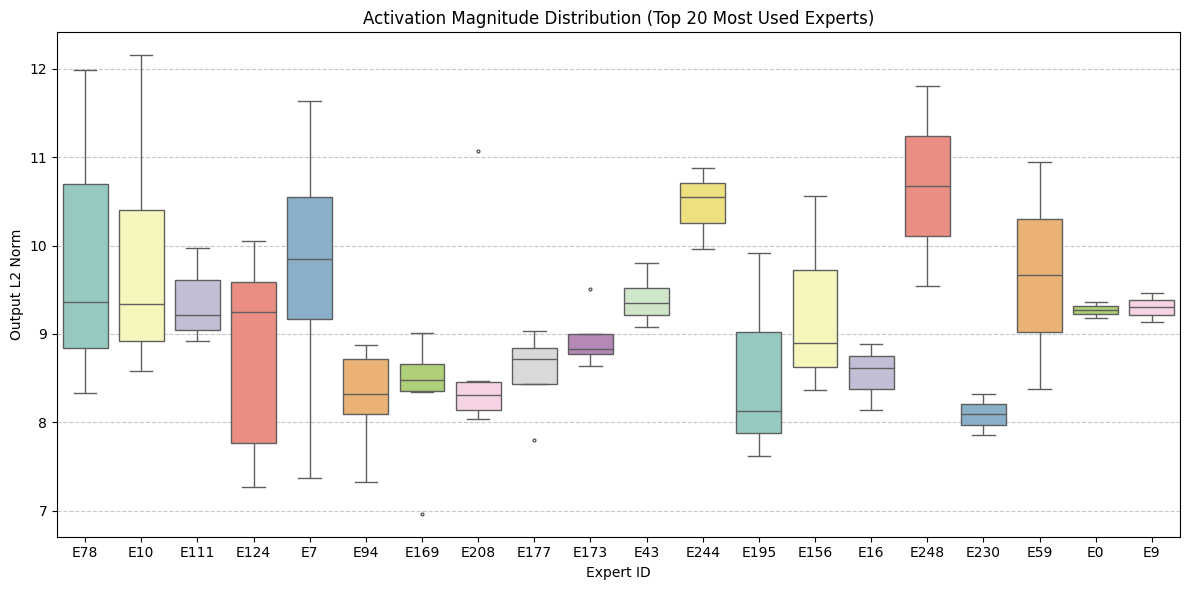

Generating Interactive Token-level Expert Attribution...
✅ Interactive HTML saved to interactive_token_attribution.html


Token,Expert Contributions



✅ 分析與視覺化完成！


In [3]:
import os
import gc
import sys
import argparse
import numpy as np
import torch
import sentencepiece as spm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.utils.checkpoint import checkpoint

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--prompt", type=str, default="The meaning of life is")
    parser.add_argument("--checkpoint", type=str, default="/Users/hungwei/Downloads/mamba3_colab_checkpoint.pt")
    parser.add_argument("--tokenizer", type=str, default="/Users/hungwei/Desktop/Proj/Mamba3-XR/data/spm_tokenizer.model")
    parser.add_argument("--max_tokens", type=int, default=32)
    parser.add_argument("--temp", type=float, default=0.7)
    parser.add_argument("--top_k", type=int, default=200)
    parser.add_argument("--top_p", type=float, default=0.95)
    parser.add_argument("--rep_pen", type=float, default=1.15)
    parser.add_argument("--pres_pen", type=float, default=0.1)
    parser.add_argument("--device", type=str, default=None)

    args = parser.parse_args(args=[])
    DEVICE = args.device if args.device else ("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

    if not os.path.exists(args.tokenizer):
        print(f"⚠️ Tokenizer 檔案不存在: {args.tokenizer}")
        sys.exit(1)

    tokenizer = spm.SentencePieceProcessor(model_file=args.tokenizer)
    NUM_EXPERTS = 256
    config = Mamba3Config(d_model=768, d_state=64, expand=4, num_layers=5, vocab_size=tokenizer.vocab_size(), use_parallel_scan=False, chunk_size=64, use_kmoe=True, kmoe_num_experts=NUM_EXPERTS, mimo_rank=4, kmoe_top_k=4)
    model = Mamba3LanguageModel(config, vocab_size=config.vocab_size)
    
    # 💡 修正 1：變數改名為 ckpt，避免覆蓋 PyTorch 的 checkpoint 函數
    if os.path.exists(args.checkpoint):
        ckpt = torch.load(args.checkpoint, map_location="cpu", weights_only=False)
        new_state = {k[10:] if k.startswith("_orig_mod.") else (k[7:] if k.startswith("module.") else k): v for k, v in ckpt["model"].items()}
        # 💡 加上 strict=False 確保 layer_scales 能夠順利載入
        model.load_state_dict(new_state, strict=False)
        del ckpt, new_state; gc.collect()
        print("✅ Model loaded")

    model = model.to(device=DEVICE, dtype=torch.float32)

    # ==========================================
    # 🩺 修正 2：將模型健康檢查與繪圖整合至 Main
    # ==========================================
    print("🔍 進行模型健康檢查與繪製 Real State Magnitude...")
    model.eval()
    layer_magnitudes = [] 
    hooks = []

    def get_hook(layer_name, layer_idx):
        def hook(module, input, output):
            hidden_states = output[0].detach().float() 
            scale = model.backbone.layer_scales[layer_idx].detach().float()
            scaled_states = hidden_states * scale.view(1, 1, -1)
            mags_per_token = scaled_states[0].norm(p=2, dim=-1).cpu().numpy()
            layer_magnitudes.append((layer_name, mags_per_token))
        return hook

    # 掛載 Hook
    layer_idx = 0
    for i, layer_dict in enumerate(model.backbone.layers):
        l_type = model.backbone.layer_types[i]
        name = f"L{layer_idx} ({'M' if l_type == 'mamba' else 'T'})"
        handle = layer_dict['block'].register_forward_hook(get_hook(name, layer_idx))
        hooks.append(handle)
        layer_idx += 1

    # 執行 Dummy Forward
    print("🚀 正在進行前向傳播抓取數據...")
    seq_len = 128
    dummy_input = torch.randint(0, tokenizer.vocab_size(), (1, seq_len)).to(DEVICE)
    ac_device = "cuda" if "cuda" in DEVICE else "cpu"
    ac_dtype = torch.float16 if "cuda" in DEVICE else torch.bfloat16
    
    with torch.no_grad(), torch.autocast(device_type=ac_device, dtype=ac_dtype):
        _ = model(dummy_input)

    # 繪製健康檢查熱力圖
    print("📊 正在繪製 Mamba/Transformer 狀態量級熱力圖 (真實強度)...")
    num_layers = len(layer_magnitudes)
    data = np.zeros((num_layers, seq_len))
    layer_labels = []

    for l in range(num_layers):
        layer_name, mags = layer_magnitudes[l]
        actual_len = min(len(mags), seq_len)
        data[l, :actual_len] = mags[:actual_len]
        layer_labels.append(layer_name)

    plt.figure(figsize=(14, 8))
    plt.imshow(data, aspect='auto', cmap='viridis', interpolation='nearest')
    plt.colorbar(label='Real State L2 Magnitude (After LayerScale)')
    plt.yticks(ticks=np.arange(num_layers), labels=layer_labels)
    plt.xlabel('Generated Tokens (Time step)')
    plt.ylabel('Layers')
    plt.title('Mamba/Transformer Real State Magnitude Progression')
    plt.tight_layout()
    plt.show()

    # 💡 移除 Hooks，確保不會影響後續正常生成的效能計算
    for handle in hooks:
        handle.remove()

    # ==========================================
    # 執行正常生成與效能擷取
    # ==========================================
    print("\n🚀 開始執行文本生成...")
    metrics = generate_stream_with_metrics(
        model, tokenizer, args.prompt, args.max_tokens, args.temp, args.top_k, args.top_p, args.rep_pen, args.pres_pen, DEVICE
    )

    # 📊 完美接上你的分析輸出格式
    print("-" * 60)
    print(f"⏱️  Time To First Token (TTFT) : {metrics['ttft']:.3f} s")
    print(f"⏱️  Time Per Output Token (TPOT): {metrics['tpot']:.3f} s/token")
    print("-" * 60)
    print(f"📊  Prefill TPS               : {metrics['prefill_throughput']:.2f} tokens/s")
    print(f"📊  Decode TPS                : {metrics['decode_throughput']:.2f} tokens/s")
    print("-" * 60)
    print(f"🧠  Avg Token Entropy         : {metrics['avg_entropy']:.3f} bits  (Higher = More Uncertainty)")
    print(f"🗃️  Final KV/SSM Cache Size   : {metrics['cache_size_mb']:.2f} MB")
    if DEVICE in ["cuda", "mps"]:
        print(f"💾  Peak Mem Allocated        : {metrics['peak_mem_allocated']:.2f} MB")
    print("=" * 60)

    # 💾 儲存歷史記錄檔案
    torch.save(metrics['state_history'], "mamba_state_history.pt")
    print("📈 State history saved to 'mamba_state_history.pt' for visualization.")
    torch.save(metrics['moe_history'], "moe_history.pt")
    print("📈 MoE history saved to 'moe_history.pt' for visualization.")
    print("-" * 60)

    # 🎨 自動觸發繪圖腳本
    plot_state_magnitudes()

    indices, probs, norms, _ = load_and_parse_moe_data("moe_history.pt", NUM_EXPERTS)
    plot_co_activation_matrix(indices, NUM_EXPERTS)
    plot_utilization_vs_magnitude(indices, norms, NUM_EXPERTS)
    plot_top_experts_boxplot(indices, norms)

    if "tokens" in metrics and metrics["tokens"]:
        generate_interactive_token_attribution(metrics["tokens"], indices, probs, norms)

    print("\n✅ 分析與視覺化完成！")

🔍 開始載入模型進行健康檢查...
✅ 模型載入完成！
🚀 正在進行前向傳播抓取數據...
📊 正在繪製 Mamba/Transformer 狀態量級熱力圖 (真實強度)...


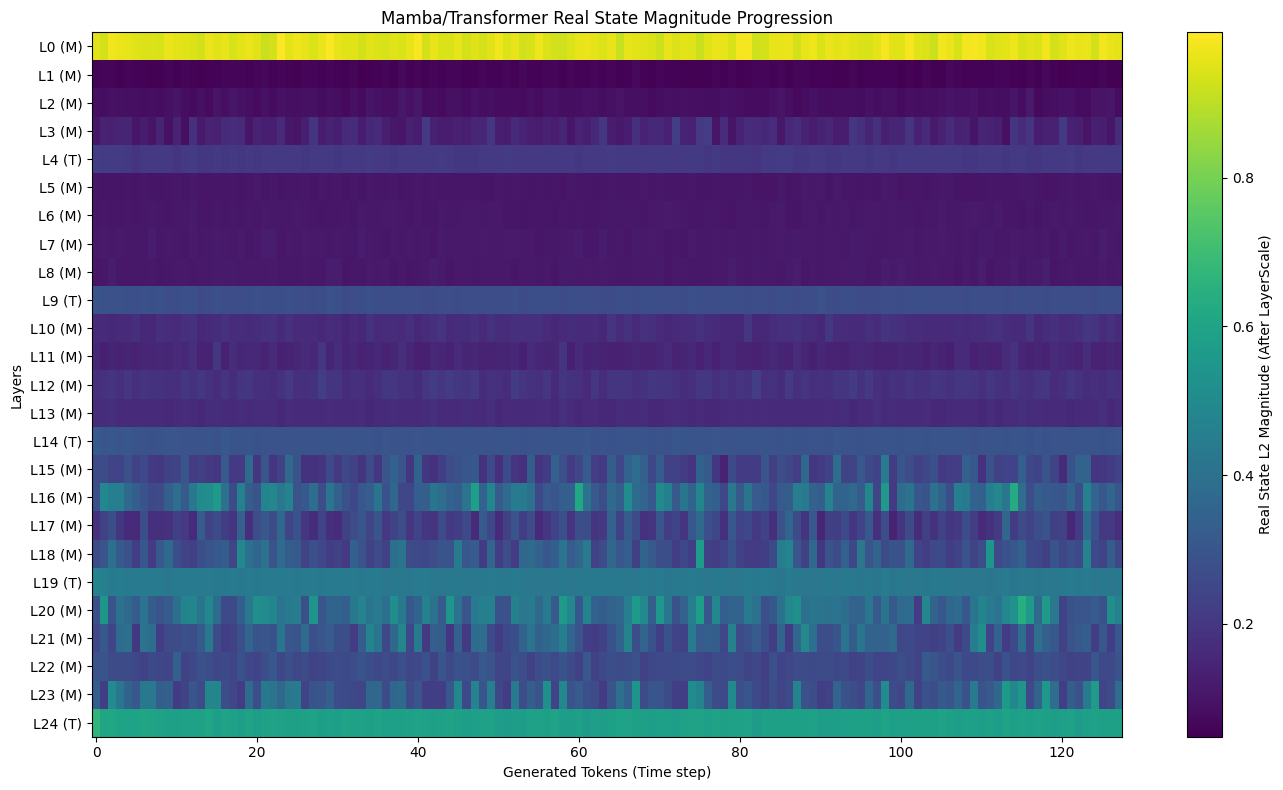

In [4]:
# ==========================================
# 視覺化體檢腳本 (修正 LayerScale 版)：check_health.py
# ==========================================
import torch
import matplotlib.pyplot as plt
from torch.utils.checkpoint import checkpoint
import numpy as np
import os   

# 如果在同一個 Notebook 中，請確保以下 Class 已經被定義
# from train import Mamba3Config, Mamba3LanguageModel

def run_health_check_and_plot(checkpoint_path="/Users/hungwei/Downloads/mamba3_colab_checkpoint.pt", seq_len=128):
    print("🔍 開始載入模型進行健康檢查...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. 初始化模型 (請確保 config 參數與您訓練時完全一致)
    config = Mamba3Config(
        d_model=768, d_state=64, expand=4, num_layers=5, 
        use_parallel_scan=True, chunk_size=64, use_kmoe=True, 
        kmoe_num_experts=256, mimo_rank=4, kmoe_top_k=4
    )
    model = Mamba3LanguageModel(config, vocab_size=32000).to(device)
    
    # 2. 載入 Checkpoint (strict=False 確保順利載入 layer_scales)
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt["model"], strict=False)
        print("✅ 模型載入完成！")
    else:
        print("⚠️ 找不到 Checkpoint，這將使用隨機初始化的權重進行測試。")

    model.eval()

    # 3. 準備 Hook 來擷取「乘上 LayerScale 後」的真實輸出 Magnitude
    layer_magnitudes = [] 

    def get_hook(layer_name, layer_idx):
        def hook(module, input, output):
            # 取得 Block 的原始輸出 (尚未乘上 LayerScale)
            # output 是一個 tuple: (out_tensor, lb_loss, z_loss)
            hidden_states = output[0].detach().float() 
            
            # 🚀 取得這一層對應的 LayerScale 參數
            scale = model.backbone.layer_scales[layer_idx].detach().float()
            
            # 🚀 將原始輸出乘上 Scale (需使用 view 改變形狀以支援廣播機制)
            # hidden_states 形狀: (Batch=1, SeqLen, D_model)
            # scale 形狀: (D_model) -> (1, 1, D_model)
            scaled_states = hidden_states * scale.view(1, 1, -1)
            
            # 計算每個 Token 在特徵維度上的 L2 Norm (真實貢獻量)
            mags_per_token = scaled_states[0].norm(p=2, dim=-1).cpu().numpy()
            layer_magnitudes.append((layer_name, mags_per_token))
        return hook

    # 掛載 Hook 到所有的 Mamba 和 Transformer Block
    layer_idx = 0
    for i, layer_dict in enumerate(model.backbone.layers):
        l_type = model.backbone.layer_types[i]
        name = f"L{layer_idx} ({'M' if l_type == 'mamba' else 'T'})"
        
        # 這裡將 layer_idx 一併傳入，才能準確抓到對應的 LayerScale
        layer_dict['block'].register_forward_hook(get_hook(name, layer_idx))
        layer_idx += 1

    # 4. 生成假資料進行前向傳播 (Forward Pass)
    print("🚀 正在進行前向傳播抓取數據...")
    dummy_input = torch.randint(0, 32000, (1, seq_len)).to(device)
    
    # 自動判斷 autocast 類型 (避免在 CPU 環境下使用 CUDA autocast 報錯)
    ac_device = "cuda" if torch.cuda.is_available() else "cpu"
    ac_dtype = torch.float16 if torch.cuda.is_available() else torch.bfloat16
    
    with torch.no_grad():
        with torch.autocast(device_type=ac_device, dtype=ac_dtype):
            _ = model(dummy_input)

    # 5. 繪製熱力圖
    print("📊 正在繪製 Mamba/Transformer 狀態量級熱力圖 (真實強度)...")
    num_layers = len(layer_magnitudes)
    num_tokens = seq_len
    data = np.zeros((num_layers, num_tokens))
    layer_labels = []

    for l in range(num_layers):
        layer_name, mags = layer_magnitudes[l]
        # 防呆機制：確保維度一致
        actual_len = min(len(mags), num_tokens)
        data[l, :actual_len] = mags[:actual_len]
        layer_labels.append(layer_name)

    plt.figure(figsize=(14, 8))
    # 這裡移除了限制最高亮度的 vmax，讓真實的數據分佈自然呈現
    plt.imshow(data, aspect='auto', cmap='viridis', interpolation='nearest')
    plt.colorbar(label='Real State L2 Magnitude (After LayerScale)')
    plt.yticks(ticks=np.arange(num_layers), labels=layer_labels)
    plt.xlabel('Generated Tokens (Time step)')
    plt.ylabel('Layers')
    plt.title('Mamba/Transformer Real State Magnitude Progression')
    plt.tight_layout()
    
    
    plt.show()

if __name__ == "__main__":
    run_health_check_and_plot()